In [ ]:
# Installazione delle librerie principali necessarie per l'esperimento con Noise2Void.
# Vengono fissate versioni specifiche di NumPy, SciPy, scikit-image, h5py,
# pandas e TensorFlow per ridurre problemi di compatibilità nell'ambiente Kaggle.
# TensorFlow viene utilizzato da N2V/CSBDeep per l'addestramento della rete neurale
!pip install -q --no-cache-dir --force-reinstall \
    "numpy==1.26.4" \
    "scipy==1.13.1" \
    "scikit-image==0.24.0" \
    "h5py==3.11.0" \
    "pandas==2.2.2" \
    "tensorflow==2.19.0" \
    "pillow" \
    "matplotlib" \
    "tqdm"
!pip uninstall -y jax jaxlib

In [2]:
%cd /kaggle/working

!rm -rf n2v
# Cloniamo il repository ufficiale di Noise2Void sviluppato da JUGLab.
!git clone https://github.com/juglab/n2v.git

%cd /kaggle/working/n2v

!pip install -e . --no-deps # Installiamo N2V in modalità editable.
!pip install -q --no-cache-dir --force-reinstall "csbdeep==0.7.4" --no-deps # Installiamo CSBDeep, libreria su cui si basa N2V.

/kaggle/working
Cloning into 'n2v'...
remote: Enumerating objects: 1220, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 1220 (delta 98), reused 70 (delta 70), pack-reused 1065 (from 3)
Receiving objects: 100% (1220/1220), 75.73 MiB | 38.62 MiB/s, done.
Resolving deltas: 100% (574/574), done.
/kaggle/working/n2v
Obtaining file:///kaggle/working/n2v
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for n2v (pyproject.toml) ... done
  Created wheel for n2v: filename=n2v-0.3.3-0.editable-py2.py3-none-any.whl size=11387 sha256=c774930357f6c92ea746e46b48487f67c415ebaec65b07afb45287a6de8ddab3
  Stored in directory: /tmp/pip-ephem-wheel-cache-oqlswi7t/wheels/6a/03/4a/4bd26ed4cb2a74609e199a0b0cf0e86b0f6d5e4a14f1f16810
Successfully built n2v
  Attempti

In [3]:
from pathlib import Path
import csbdeep

# -----------------------------
# Patch 1: CSBDeep config.py
# -----------------------------
config_path = Path(csbdeep.__file__).parent / "models" / "config.py"

print("Patch CSBDeep config:", config_path)

text = config_path.read_text(errors="ignore")

#Le versioni moderne di Keras richiedono che, quando si salvano solo i pesi del modello
#il file termini con: .weights.h5
text = text.replace("weights_best.h5", "weights_best.weights.h5")
text = text.replace("weights_now.h5", "weights_now.weights.h5")
text = text.replace("weights_last.h5", "weights_last.weights.h5")

config_path.write_text(text)


# -----------------------------
# Patch 2: N2V n2v_standard.py
# -----------------------------
n2v_standard_path = Path("/kaggle/working/n2v/n2v/models/n2v_standard.py")

print("Patch N2V standard:", n2v_standard_path)

text = n2v_standard_path.read_text(errors="ignore")

text = text.replace("weights_best.h5", "weights_best.weights.h5")
text = text.replace("weights_now.h5", "weights_now.weights.h5")
text = text.replace("weights_last.h5", "weights_last.weights.h5")

n2v_standard_path.write_text(text)


# -----------------------------
# Patch 3: CSBDeep TensorBoard callback
# -----------------------------
tf_utils_path = Path(csbdeep.__file__).parent / "utils" / "tf.py"

print("Patch CSBDeep tf.py:", tf_utils_path)

text = tf_utils_path.read_text(errors="ignore")

text = text.replace("self.model = model", "self._model = model")

tf_utils_path.write_text(text)

print("Patch completate.")

Patch CSBDeep config: /usr/local/lib/python3.12/dist-packages/csbdeep/models/config.py
Patch N2V standard: /kaggle/working/n2v/n2v/models/n2v_standard.py
Patch CSBDeep tf.py: /usr/local/lib/python3.12/dist-packages/csbdeep/utils/tf.py
Patch completate.


In [4]:
%cd /kaggle/working/n2v

import numpy as np
import scipy
import skimage
import h5py
import tensorflow as tf
import csbdeep

#print("NumPy:", np.__version__)
#print("SciPy:", scipy.__version__)
#print("Scikit-image:", skimage.__version__)
#print("h5py:", h5py.__version__)
#print("TensorFlow:", tf.__version__)
#print("CSBDeep:", csbdeep.__version__)
#print("GPU:", tf.config.list_physical_devices("GPU"))

from n2v.models import N2VConfig, N2V
from n2v.internals.N2V_DataGenerator import N2V_DataGenerator

print("N2V importato correttamente")

/kaggle/working/n2v


2026-05-15 18:02:22.329574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778868142.353495     162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778868142.361055     162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778868142.379758     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778868142.379779     162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778868142.379782     162 computation_placer.cc:177] computation placer alr

N2V importato correttamente


In [5]:
#from pathlib import Path
from PIL import Image
from tqdm import tqdm

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [9]:
# -----------------------------
# CLEAN DATASET
# -----------------------------

kodak_clean_dir = Path("/kaggle/input/datasets/sherylmehta/kodak-dataset")

bsd500_clean_dir = Path(
    "/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images"
)

div2k_clean_dir = Path(
    "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images"
)



# -----------------------------
# NOISY GAUSSIAN DATASET
# -----------------------------

kodak_noisy_dir = Path(
    "/kaggle/input/notebooks/antoiann/impulsivenoise/kodak_random_impulse_p010"
)

bsd500_noisy_dir = Path(
    "/kaggle/input/notebooks/antoiann/impulsivenoise/bsd500_random_impulse_p010"
)

div2k_noisy_dir = Path(
    "/kaggle/input/notebooks/antoiann/impulsivenoise/div2k_random_impulse_p010"
)


# -----------------------------
# OUTPUT N2V
# -----------------------------

kodak_output_dir = Path("/kaggle/working/kodak_impulsive_n2v_denoised")
bsd500_output_dir = Path("/kaggle/working/bsd500_impulsive_n2v_denoised")
div2k_output_dir = Path("/kaggle/working/div2k_impulsive_n2v_denoised")

for d in [kodak_output_dir, bsd500_output_dir, div2k_output_dir]:
    d.mkdir(parents=True, exist_ok=True)

In [10]:
def get_image_paths(input_dir):
    """
    Restituisce tutti i path delle immagini contenute in input_dir,
    includendo eventuali sottocartelle.
    """

    input_dir = Path(input_dir)

    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

    image_paths = [
        p for p in input_dir.rglob("*")
        if p.suffix.lower() in image_extensions
    ]

    return sorted(image_paths)

In [11]:
kodak_noisy_paths = get_image_paths(kodak_noisy_dir)
bsd500_noisy_paths = get_image_paths(bsd500_noisy_dir)
div2k_noisy_paths = get_image_paths(div2k_noisy_dir)

print("Kodak noisy:", len(kodak_noisy_paths))
print("BSD500 noisy:", len(bsd500_noisy_paths))
print("DIV2K noisy:", len(div2k_noisy_paths))

Kodak noisy: 24
BSD500 noisy: 500
DIV2K noisy: 900


In [12]:
# BSD500 noisy split
bsd500_train_noisy_dir = bsd500_noisy_dir / "train"
bsd500_val_noisy_dir   = bsd500_noisy_dir / "val"
bsd500_test_noisy_dir  = bsd500_noisy_dir / "test"

# BSD500 clean split
bsd500_train_clean_dir = bsd500_clean_dir / "train"
bsd500_val_clean_dir   = bsd500_clean_dir / "val"
bsd500_test_clean_dir  = bsd500_clean_dir / "test"


# DIV2K noisy split
div2k_train_noisy_dir = div2k_noisy_dir / "DIV2K_train_HR"/ "DIV2K_train_HR"
div2k_valid_noisy_dir = div2k_noisy_dir / "DIV2K_valid_HR"/ "DIV2K_valid_HR"

div2k_train_clean_dir = Path(
    "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR"
)

div2k_valid_clean_dir = Path(
    "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR"
)

In [13]:
bsd500_train_noisy_paths = get_image_paths(bsd500_train_noisy_dir)
bsd500_val_noisy_paths   = get_image_paths(bsd500_val_noisy_dir)
bsd500_test_noisy_paths  = get_image_paths(bsd500_test_noisy_dir)

In [14]:
div2k_train_noisy_paths = get_image_paths(div2k_train_noisy_dir)
div2k_val_noisy_paths = get_image_paths(div2k_valid_noisy_dir)

train_noisy_paths = bsd500_train_noisy_paths + div2k_train_noisy_paths
val_noisy_paths = bsd500_val_noisy_paths + div2k_val_noisy_paths

print("Training images:", len(train_noisy_paths))
print("Validation images:", len(val_noisy_paths))

Training images: 1000
Validation images: 200


In [16]:
def extract_random_patches_from_paths(
    image_paths,
    patch_size=64,
    patches_per_image=30,
    max_images=None,
    seed=42
):
    """
    Estrae patch casuali da una lista di immagini salvate su disco.

    image_paths: lista dei percorsi delle immagini rumorose
    patch_size: dimensione della patch quadrata, ad esempio 64 -> 64x64
    patches_per_image: numero di patch da estrarre da ogni immagine
    max_images: numero massimo opzionale di immagini da usare
    seed: seed per rendere l'estrazione riproducibile

    Ritorna:
    - patches: array numpy con shape (N, patch_size, patch_size, 3)
    """

    rng = np.random.default_rng(seed)

    if max_images is not None:
        image_paths = image_paths[:max_images]

    patches = []

    for img_path in tqdm(image_paths):
        # lettura immagine RGB
        img = Image.open(img_path).convert("RGB")

        # conversione in numpy e normalizzazione in [0, 1]
        img = np.array(img).astype(np.float32) / 255.0

        h, w, c = img.shape

        # se l'immagine è più piccola della patch, la saltiamo
        if h < patch_size or w < patch_size:
            print("Immagine troppo piccola, saltata:", img_path)
            continue

        for _ in range(patches_per_image):
            y = rng.integers(0, h - patch_size + 1)
            x = rng.integers(0, w - patch_size + 1)

            patch = img[y:y + patch_size, x:x + patch_size, :]
            patches.append(patch)

    patches = np.array(patches, dtype=np.float32)

    print("Patch create:", patches.shape)

    return patches

In [17]:
# Estrazione delle patch dal training set.
# Da ogni immagine rumorosa di training vengono estratte 30 patch casuali
# di dimensione 64x64 pixel.

X_train = extract_random_patches_from_paths(
    train_noisy_paths,
    patch_size=64,
    patches_per_image=30,
    seed=42
)
# Estrazione delle patch dal validation set.
# Da ogni immagine rumorosa di validation vengono estratte 10 patch casuali.
X_val = extract_random_patches_from_paths(
    val_noisy_paths,
    patch_size=64,
    patches_per_image=10,
    seed=123
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
# (numero_patch, altezza_patch, larghezza_patch, canali)

100%|██████████| 1000/1000 [01:44<00:00,  9.55it/s]


Patch create: (30000, 64, 64, 3)


100%|██████████| 200/200 [00:12<00:00, 16.42it/s]

Patch create: (2000, 64, 64, 3)
X_train: (30000, 64, 64, 3)
X_val: (2000, 64, 64, 3)


In [18]:
config = N2VConfig(
    X_train,
    unet_kern_size=3,
    unet_n_first=64,
    unet_n_depth=3,
    train_steps_per_epoch=500,
    train_epochs=30,
    train_loss='mse',
    train_learning_rate=2e-5,
    batch_norm=True,
    train_batch_size=8,
    n2v_perc_pix=0.198,
    n2v_patch_shape=(64, 64),
    n2v_manipulator='uniform_withCP',
    n2v_neighborhood_radius=5,
    single_net_per_channel=False
)
# Le versioni moderne di Keras richiedono che i file dei pesi,
# quando salvati con save_weights_only=True, terminino con ".weights.h5".
# Per questo motivo controlliamo se l'oggetto config possiede gli attributi
# relativi ai checkpoint e, se esistono, li aggiorniamo manualmente.

# Nome del file in cui verranno salvati i pesi migliori del modello.
if hasattr(config, "train_checkpoint"):
    config.train_checkpoint = "weights_best.weights.h5"
# Nome del file in cui verranno salvati i pesi dell'ultima epoca.
if hasattr(config, "train_checkpoint_last"):
    config.train_checkpoint_last = "weights_last.weights.h5"
# Nome del file in cui verranno salvati i pesi intermedi/correnti.
if hasattr(config, "train_checkpoint_epoch"):
    config.train_checkpoint_epoch = "weights_now.weights.h5"

for key, value in vars(config).items():
    if "checkpoint" in key.lower() or ".h5" in str(value):
        print(key, "=", value)

train_checkpoint = weights_best.weights.h5


In [19]:
model = N2V(
    config,
    name="n2v_impulsive_010",
    basedir="/kaggle/working/models"
)

I0000 00:00:1778868389.044318     162 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778868389.046386     162 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
history = model.train(X_train, X_val)

8 blind-spots will be generated per training patch of size (64, 64).


Preparing validation data: 100%|██████████| 2000/2000 [00:01<00:00, 1269.50it/s]


Epoch 1/30


I0000 00:00:1778868416.128169     296 service.cc:152] XLA service 0x7b5d4400eb30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778868416.128209     296 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778868416.128213     296 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778868417.950571     296 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 18:07:00.735931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:07:00.883499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:07:01.209683: E external/local_xl

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0671 - n2v_abs: 0.7942 - n2v_mse: 1.0671

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 64, 64, 3))',)
  warnings.warn(msg)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 0.7840 - n2v_abs: 0.6711 - n2v_mse: 0.7840 - val_loss: 0.4426 - val_n2v_abs: 0.4634 - val_n2v_mse: 0.4436 - learning_rate: 2.0000e-05
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/stepstep - loss: 0.4117 - n2v_abs: 0.4760 - n2v_mse: 0.411
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.3828 - n2v_abs: 0.4579 - n2v_mse: 0.3828 - val_loss: 0.3131 - val_n2v_abs: 0.3710 - val_n2v_mse: 0.3144 - learning_rate: 2.0000e-05
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/stepstep - loss: 0.3460 - n2v_abs: 0.4329 - n2v_mse: 0.346
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.3372 - n2v_abs: 0.4252 - n2v_mse: 0.3372 - val_loss: 0.2911 - val_n2v_abs: 0.3559 - val_n2v_mse: 0.2924 - learning_rate: 2.0000e-05
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/stepstep - loss: 0.2977 - n2v_abs: 0.3951 - n2v_mse: 0.297
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.2953 - n2v_abs: 0.3964 - n2v_mse: 0.2953 - va

In [21]:
def denoise_dataset_with_n2v(
    model,
    noisy_dir,
    clean_dir,
    output_dir,
    csv_name="metrics.csv"
):
    """
    Applica un modello N2V a tutte le immagini rumorose di noisy_dir,
    salva le immagini denoised in output_dir e calcola PSNR/SSIM.
    """

    noisy_dir = Path(noisy_dir)
    clean_dir = Path(clean_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    noisy_paths = get_image_paths(noisy_dir)

    results = []

    for noisy_path in tqdm(noisy_paths):
        try:
            relative_path = noisy_path.relative_to(noisy_dir)
            clean_path = clean_dir / relative_path

            if not clean_path.exists():
                print("Clean non trovata:", clean_path)
                continue

            noisy_img = Image.open(noisy_path).convert("RGB")
            noisy_np = np.array(noisy_img).astype(np.float32) / 255.0

            pred = model.predict(noisy_np, axes="YXC")
            pred = np.clip(pred, 0, 1)

            save_path = output_dir / relative_path
            save_path = save_path.with_suffix(".png")
            save_path.parent.mkdir(parents=True, exist_ok=True)

            Image.fromarray((pred * 255).astype(np.uint8)).save(save_path)

            clean_img = Image.open(clean_path).convert("RGB")
            clean_img = clean_img.resize((noisy_np.shape[1], noisy_np.shape[0]))
            clean_np = np.array(clean_img).astype(np.float32) / 255.0

            psnr_noisy = psnr(clean_np, noisy_np, data_range=1.0)
            ssim_noisy = ssim(clean_np, noisy_np, channel_axis=2, data_range=1.0)

            psnr_n2v = psnr(clean_np, pred, data_range=1.0)
            ssim_n2v = ssim(clean_np, pred, channel_axis=2, data_range=1.0)

            results.append({
                "filename": str(relative_path),
                "clean_path": str(clean_path),
                "noisy_path": str(noisy_path),
                "denoised_path": str(save_path),
                "psnr_clean_noisy": float(psnr_noisy),
                "ssim_clean_noisy": float(ssim_noisy),
                "psnr_clean_n2v": float(psnr_n2v),
                "ssim_clean_n2v": float(ssim_n2v),
                "psnr_gain": float(psnr_n2v - psnr_noisy),
                "ssim_gain": float(ssim_n2v - ssim_noisy),
            })

        except Exception as e:
            print("Errore su:", noisy_path)
            print(e)

    df = pd.DataFrame(results)

    csv_path = output_dir / csv_name
    df.to_csv(csv_path, index=False)

    print("CSV salvato in:", csv_path)

    if len(df) > 0:
        print("PSNR medio clean/noisy:", df["psnr_clean_noisy"].mean())
        print("PSNR medio clean/N2V:", df["psnr_clean_n2v"].mean())
        print("Gain PSNR medio:", df["psnr_gain"].mean())

        print("SSIM medio clean/noisy:", df["ssim_clean_noisy"].mean())
        print("SSIM medio clean/N2V:", df["ssim_clean_n2v"].mean())
        print("Gain SSIM medio:", df["ssim_gain"].mean())

    return df

In [22]:
def show_n2v_result(noisy_dir, clean_dir, denoised_dir, index=0):
    """
    Visualizza il confronto tra:
    - immagine clean originale
    - immagine rumorosa
    - immagine denoised prodotta da N2V

    Inoltre calcola PSNR e SSIM:
    - clean/noisy
    - clean/N2V

    noisy_dir: cartella delle immagini rumorose
    clean_dir: cartella delle immagini pulite corrispondenti
    denoised_dir: cartella delle immagini denoised salvate da N2V
    index: indice dell'immagine da visualizzare
    """

    noisy_dir = Path(noisy_dir)
    clean_dir = Path(clean_dir)
    denoised_dir = Path(denoised_dir)

    noisy_paths = get_image_paths(noisy_dir)

    if len(noisy_paths) == 0:
        print("Nessuna immagine rumorosa trovata.")
        return

    if index >= len(noisy_paths):
        print("Indice fuori range.")
        print("Numero immagini disponibili:", len(noisy_paths))
        return

    noisy_path = noisy_paths[index]

    # Percorso relativo rispetto alla cartella noisy
    relative_path = noisy_path.relative_to(noisy_dir)

    # Clean corrispondente
    clean_path = clean_dir / relative_path

    # Denoised corrispondente
    denoised_path = denoised_dir / relative_path
    denoised_path = denoised_path.with_suffix(".png")

    print("Clean:", clean_path)
    print("Noisy:", noisy_path)
    print("Denoised:", denoised_path)

    if not clean_path.exists():
        print("Errore: immagine clean non trovata.")
        return

    if not noisy_path.exists():
        print("Errore: immagine noisy non trovata.")
        return

    if not denoised_path.exists():
        print("Errore: immagine denoised non trovata.")
        print("Controlla che esista:", denoised_path.exists())
        return

    # Lettura immagini
    clean_img = Image.open(clean_path).convert("RGB")
    noisy_img = Image.open(noisy_path).convert("RGB")
    denoised_img = Image.open(denoised_path).convert("RGB")

    # Uniforma dimensioni, se necessario
    noisy_img = noisy_img.resize(clean_img.size)
    denoised_img = denoised_img.resize(clean_img.size)

    # Conversione in numpy [0, 1]
    clean_np = np.array(clean_img).astype(np.float32) / 255.0
    noisy_np = np.array(noisy_img).astype(np.float32) / 255.0
    denoised_np = np.array(denoised_img).astype(np.float32) / 255.0

    # Metriche
    psnr_noisy = psnr(clean_np, noisy_np, data_range=1.0)
    ssim_noisy = ssim(clean_np, noisy_np, channel_axis=2, data_range=1.0)

    psnr_denoised = psnr(clean_np, denoised_np, data_range=1.0)
    ssim_denoised = ssim(clean_np, denoised_np, channel_axis=2, data_range=1.0)

    # Visualizzazione
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(clean_np)
    plt.title("Clean originale")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(noisy_np)
    plt.title(
        f"Noisy Random-Valued Impulse Noise p=0.10\n"
        f"PSNR: {psnr_noisy:.2f} dB | SSIM: {ssim_noisy:.4f}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(denoised_np)
    plt.title(
        f"N2V denoised\n"
        f"PSNR: {psnr_denoised:.2f} dB | SSIM: {ssim_denoised:.4f}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("PSNR clean/noisy:", psnr_noisy)
    print("SSIM clean/noisy:", ssim_noisy)
    print("PSNR clean/N2V:", psnr_denoised)
    print("SSIM clean/N2V:", ssim_denoised)
    print("Gain PSNR:", psnr_denoised - psnr_noisy)
    print("Gain SSIM:", ssim_denoised - ssim_noisy)

In [23]:
def denoise_dataset_with_n2v_div2k(
    model,
    noisy_dir,
    clean_dir,
    output_dir,
    csv_name="metrics.csv"
):
    """
    Applica un modello N2V a tutte le immagini rumorose di noisy_dir,
    salva le immagini denoised in output_dir e calcola PSNR/SSIM.
    """

    noisy_dir = Path(noisy_dir)
    clean_dir = Path(clean_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    noisy_paths = get_image_paths(noisy_dir)

    results = []

    for noisy_path in tqdm(noisy_paths):
        try:
            relative_path = noisy_path.relative_to(noisy_dir)
            clean_path = clean_dir / relative_path

            if not clean_path.exists():
                print("Clean non trovata:", clean_path)
                continue

            noisy_img = Image.open(noisy_path).convert("RGB")
            noisy_np = np.array(noisy_img).astype(np.float32) / 255.0

            # Sostituisci la vecchia riga con questa:
            # n_tiles=(4, 4) divide l'immagine in una griglia di 16 tasselli indipendenti.
            # La GPU processerà un tassello alla volta, alleggerendo la memoria.
            pred = model.predict(noisy_np, axes="YXC", n_tiles=(2, 2, 1))
            pred = np.clip(pred, 0, 1)

            save_path = output_dir / relative_path
            save_path = save_path.with_suffix(".png")
            save_path.parent.mkdir(parents=True, exist_ok=True)

            Image.fromarray((pred * 255).astype(np.uint8)).save(save_path)

            clean_img = Image.open(clean_path).convert("RGB")
            clean_img = clean_img.resize((noisy_np.shape[1], noisy_np.shape[0]))
            clean_np = np.array(clean_img).astype(np.float32) / 255.0

            psnr_noisy = psnr(clean_np, noisy_np, data_range=1.0)
            ssim_noisy = ssim(clean_np, noisy_np, channel_axis=2, data_range=1.0)

            psnr_n2v = psnr(clean_np, pred, data_range=1.0)
            ssim_n2v = ssim(clean_np, pred, channel_axis=2, data_range=1.0)

            results.append({
                "filename": str(relative_path),
                "clean_path": str(clean_path),
                "noisy_path": str(noisy_path),
                "denoised_path": str(save_path),
                "psnr_clean_noisy": float(psnr_noisy),
                "ssim_clean_noisy": float(ssim_noisy),
                "psnr_clean_n2v": float(psnr_n2v),
                "ssim_clean_n2v": float(ssim_n2v),
                "psnr_gain": float(psnr_n2v - psnr_noisy),
                "ssim_gain": float(ssim_n2v - ssim_noisy),
            })

        except Exception as e:
            print("Errore su:", noisy_path)
            print(e)

    df = pd.DataFrame(results)

    csv_path = output_dir / csv_name
    df.to_csv(csv_path, index=False)

    print("CSV salvato in:", csv_path)

    if len(df) > 0:
        print("PSNR medio clean/noisy:", df["psnr_clean_noisy"].mean())
        print("PSNR medio clean/N2V:", df["psnr_clean_n2v"].mean())
        print("Gain PSNR medio:", df["psnr_gain"].mean())

        print("SSIM medio clean/noisy:", df["ssim_clean_noisy"].mean())
        print("SSIM medio clean/N2V:", df["ssim_clean_n2v"].mean())
        print("Gain SSIM medio:", df["ssim_gain"].mean())

    return df

In [24]:
df_kodak = denoise_dataset_with_n2v(
    model=model,
    noisy_dir=kodak_noisy_dir,
    clean_dir=kodak_clean_dir,
    output_dir=Path("/kaggle/working/kodak_impulsive_n2v_denoised"),
    csv_name="kodak_impuksive_n2v_metrics.csv"
)

  0%|          | 0/24 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


  4%|▍         | 1/24 [00:08<03:17,  8.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  8%|▊         | 2/24 [00:09<01:23,  3.81s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


 96%|█████████▌| 23/24 [00:27<00:00,  1.91it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


100%|██████████| 24/24 [00:28<00:00,  1.18s/it]

CSV salvato in: /kaggle/working/kodak_impulsive_n2v_denoised/kodak_impuksive_n2v_metrics.csv
PSNR medio clean/noisy: 18.562952659269314
PSNR medio clean/N2V: 22.534865155109944
Gain PSNR medio: 3.9719124958406287
SSIM medio clean/noisy: 0.3417329111446937
SSIM medio clean/N2V: 0.4838094376027584
Gain SSIM medio: 0.1420765264580647


Clean: /kaggle/input/datasets/sherylmehta/kodak-dataset/kodim17.png
Noisy: /kaggle/input/notebooks/antoiann/impulsivenoise/kodak_random_impulse_p010/kodim17.png
Denoised: /kaggle/working/kodak_impulsive_n2v_denoised/kodim17.png


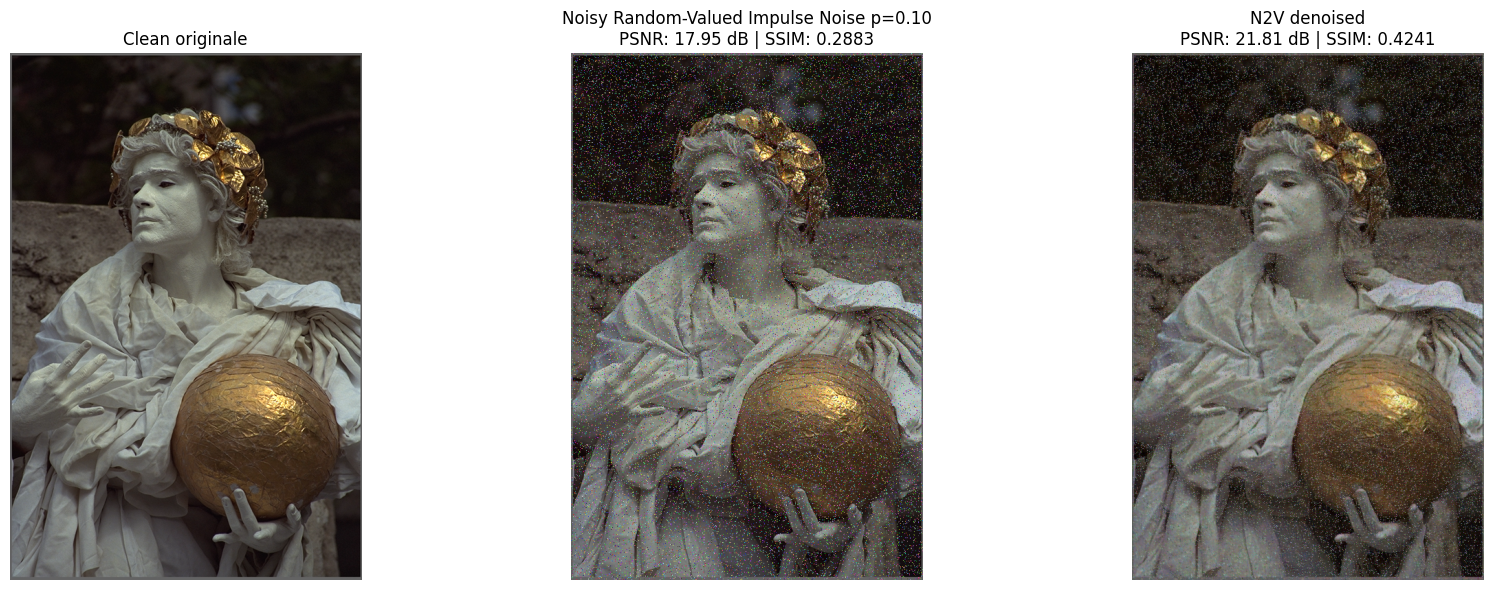

PSNR clean/noisy: 17.952514187388775
SSIM clean/noisy: 0.28833202
PSNR clean/N2V: 21.80720548595151
SSIM clean/N2V: 0.42409572
Gain PSNR: 3.8546912985627344
Gain SSIM: 0.1357637


In [25]:
show_n2v_result(
    noisy_dir=kodak_noisy_dir,
    clean_dir=kodak_clean_dir,
    denoised_dir=Path("/kaggle/working/kodak_impulsive_n2v_denoised"),
    index=16
)

In [26]:
df_bsd500_test = denoise_dataset_with_n2v(
    model=model,
    noisy_dir=bsd500_test_noisy_dir,
    clean_dir=bsd500_test_clean_dir,
    output_dir=Path("/kaggle/working/bsd500_impulsive_n2v_denoised/test"),
    csv_name="bsd500_test_impulsive_n2v_metrics.csv"
)

  0%|          | 0/200 [00:00<?, ?it/s]2026-05-15 18:16:45.450616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:16:45.658031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:16:46.299288: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:16:46.566342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:16:47.6

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


  0%|          | 1/200 [00:07<25:21,  7.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


  1%|          | 2/200 [00:07<10:49,  3.28s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


100%|█████████▉| 199/200 [01:04<00:00,  3.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


100%|██████████| 200/200 [01:04<00:00,  3.10it/s]

CSV salvato in: /kaggle/working/bsd500_impulsive_n2v_denoised/test/bsd500_test_impulsive_n2v_metrics.csv
PSNR medio clean/noisy: 19.93789786292609
PSNR medio clean/N2V: 22.126779949653663
Gain PSNR medio: 2.1888820867275767
SSIM medio clean/noisy: 0.44517339423298835
SSIM medio clean/N2V: 0.539802767187357
Gain SSIM medio: 0.09462937295436859


Clean: /kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images/test/107014.jpg
Noisy: /kaggle/input/notebooks/antoiann/impulsivenoise/bsd500_random_impulse_p010/test/107014.jpg
Denoised: /kaggle/working/bsd500_impulsive_n2v_denoised/test/107014.png


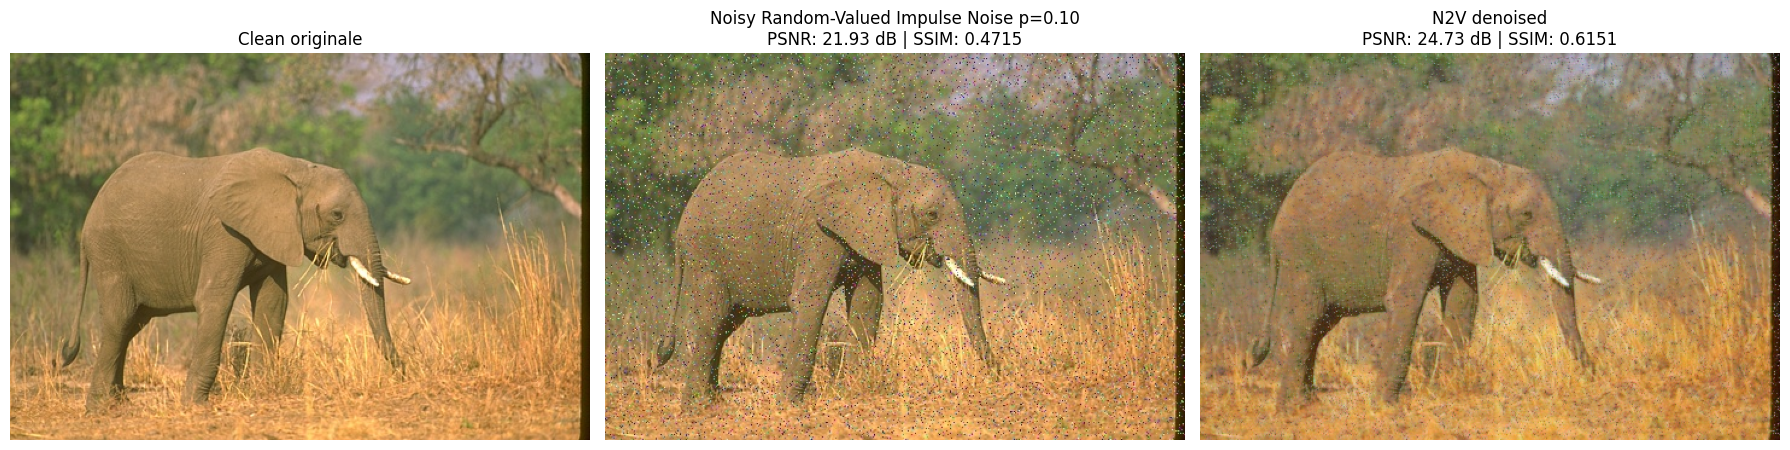

PSNR clean/noisy: 21.93017214181751
SSIM clean/noisy: 0.4714783
PSNR clean/N2V: 24.729794295805306
SSIM clean/N2V: 0.61505514
Gain PSNR: 2.7996221539877943
Gain SSIM: 0.14357683


In [27]:
show_n2v_result(
    noisy_dir=bsd500_test_noisy_dir,
    clean_dir=bsd500_test_clean_dir,
    denoised_dir=Path("/kaggle/working/bsd500_impulsive_n2v_denoised/test"),
    index=15
)

In [28]:
df_div2k = denoise_dataset_with_n2v_div2k(
    model=model,
    noisy_dir=div2k_valid_noisy_dir,
    clean_dir=div2k_valid_clean_dir,
    output_dir=div2k_output_dir / "DIV2K_valid_HR",
    csv_name="div2k_impulsive_n2v_metrics.csv"
)

  0%|          | 0/100 [00:00<?, ?it/s]2026-05-15 18:19:29.480154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:19:29.703953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:19:40.388830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 18:19:40.691616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step



 25%|██▌       | 1/4 [00:00<00:00, 1366.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step



 50%|█████     | 2/4 [00:00<00:00,  7.55it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step



 75%|███████▌  | 3/4 [00:00<00:00,  6.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step



100%|██████████| 100/100 [11:30<00:00,  6.90s/it]

CSV salvato in: /kaggle/working/div2k_impulsive_n2v_denoised/DIV2K_valid_HR/div2k_impulsive_n2v_metrics.csv
PSNR medio clean/noisy: 17.762241506932117
PSNR medio clean/N2V: 21.19262343251871
Gain PSNR medio: 3.4303819255865915
SSIM medio clean/noisy: 0.3190131118893623
SSIM medio clean/N2V: 0.4325446245074272
Gain SSIM medio: 0.11353151261806488


In [ ]:
show_n2v_result(
    noisy_dir=div2k_valid_noisy_dir,
    clean_dir=div2k_valid_clean_dir,
    denoised_dir=div2k_output_dir / "DIV2K_valid_HR",
    index=99
)